In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

np.random.seed(0)

# 0. Functions for bootstrapping and plotting

In [ ]:
def bootstrap_coef(df, fit_fn, coef_name, n_boot=3000, random_state=0):
    rng = np.random.default_rng(random_state)
    n = len(df)
    vals = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        dfb = df.iloc[idx].copy()
        model = fit_fn(dfb)
        vals.append(model.params[coef_name])

    vals = np.asarray(vals)
    ci = np.percentile(vals, [2.5, 97.5])
    return vals, ci


def bootstrap_logit_coef(df, fit_fn, coef_name, n_boot=3000, random_state=0):
    rng = np.random.default_rng(random_state)
    n = len(df)
    vals = []
    tries = 0

    while len(vals) < n_boot and tries < 5 * n_boot:
        tries += 1
        idx = rng.integers(0, n, size=n)
        dfb = df.iloc[idx].copy()
        try:
            model = fit_fn(dfb)
            vals.append(model.params[coef_name])
        except:
            pass

    vals = np.asarray(vals)
    ci = np.percentile(vals, [2.5, 97.5])
    return vals, ci


def ci_decision(ci, null_value=0):
    return "REJECT null" if not (ci[0] <= null_value <= ci[1]) else "FAIL TO REJECT null"


def plot_bootstrap(vals, ci, null_value=0, title="", xlabel="parameter"):
    plt.figure(figsize=(6, 4))
    plt.hist(vals, bins=40, alpha=0.8, edgecolor="black")
    plt.axvline(ci[0], linestyle="--", label=f"2.5% = {ci[0]:.3f}")
    plt.axvline(ci[1], linestyle="--", label=f"97.5% = {ci[1]:.3f}")
    plt.axvline(null_value, linestyle="-", label=f"null = {null_value}")
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.title(title)
    plt.legend()
    plt.show()


def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."


def add_sig_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=11)


def plot_two_group_jitter(df, x_col, y_col, labels, title="", p_value=None):
    fig, ax = plt.subplots(figsize=(5, 4))

    x_positions = np.arange(len(labels))
    means = [df.loc[df[x_col] == lab, y_col].mean() for lab in labels]

    ax.bar(x_positions, means, width=0.6, alpha=0.5, edgecolor="black")

    rng = np.random.default_rng(0)
    for i, lab in enumerate(labels):
        y = df.loc[df[x_col] == lab, y_col].values
        jitter = rng.normal(0, 0.06, size=len(y))
        ax.scatter(np.full(len(y), x_positions[i]) + jitter, y, alpha=0.75, s=30)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(y_col)
    ax.set_title(title)

    if p_value is not None:
        ymax = df[y_col].max()
        ymin = df[y_col].min()
        yr = ymax - ymin
        y = ymax + 0.06 * yr
        h = 0.04 * yr
        add_sig_bracket(ax, x_positions[0], x_positions[1], y, h, p_to_stars(p_value))

    plt.tight_layout()
    plt.show()


def plot_three_group_jitter(df, x_col, y_col, labels, title="", p_value=None):
    fig, ax = plt.subplots(figsize=(6, 4))

    x_positions = np.arange(len(labels))
    means = [df.loc[df[x_col] == lab, y_col].mean() for lab in labels]

    ax.bar(x_positions, means, width=0.6, alpha=0.5, edgecolor="black")

    rng = np.random.default_rng(1)
    for i, lab in enumerate(labels):
        y = df.loc[df[x_col] == lab, y_col].values
        jitter = rng.normal(0, 0.06, size=len(y))
        ax.scatter(np.full(len(y), x_positions[i]) + jitter, y, alpha=0.75, s=30)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(y_col)
    ax.set_title(title)

    if p_value is not None:
        ymax = df[y_col].max()
        ymin = df[y_col].min()
        yr = ymax - ymin
        y = ymax + 0.08 * yr
        h = 0.04 * yr
        add_sig_bracket(ax, x_positions[0], x_positions[-1], y, h, f"ANOVA {p_to_stars(p_value)}")

    plt.tight_layout()
    plt.show()


def plot_scatter_with_fit(x, y, xlabel, ylabel, title=""):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(x, y, alpha=0.75, s=30)

    coef = np.polyfit(x, y, 1)
    xline = np.linspace(np.min(x), np.max(x), 200)
    yline = coef[0] * xline + coef[1]
    ax.plot(xline, yline, linewidth=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_ancova_data(df, x_col, y_col, condition_col, title=""):
    fig, ax = plt.subplots(figsize=(6, 4))

    conditions = sorted(df[condition_col].unique())
    for cond in conditions:
        d = df[df[condition_col] == cond]
        ax.scatter(d[x_col], d[y_col], alpha=0.75, s=30, label=cond)

        coef = np.polyfit(d[x_col], d[y_col], 1)
        xline = np.linspace(d[x_col].min(), d[x_col].max(), 100)
        yline = coef[0] * xline + coef[1]
        ax.plot(xline, yline, linewidth=2)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.legend(title=condition_col)
    plt.tight_layout()
    plt.show()


def plot_binary_proportions(df, x_col, y_col, labels, title="", p_value=None):
    fig, ax = plt.subplots(figsize=(5, 4))

    x_positions = np.arange(len(labels))
    props = [df.loc[df[x_col] == lab, y_col].mean() for lab in labels]

    ax.bar(x_positions, props, width=0.6, alpha=0.5, edgecolor="black")

    rng = np.random.default_rng(2)
    for i, lab in enumerate(labels):
        y = df.loc[df[x_col] == lab, y_col].values.astype(float)
        jitter_x = rng.normal(0, 0.06, size=len(y))
        jitter_y = rng.normal(0, 0.02, size=len(y))
        ax.scatter(np.full(len(y), x_positions[i]) + jitter_x, y + jitter_y, alpha=0.5, s=20)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)
    ax.set_ylim(-0.1, 1.15)
    ax.set_ylabel("proportion detected / binary outcome")
    ax.set_title(title)

    if p_value is not None:
        y = 1.02
        h = 0.03
        add_sig_bracket(ax, x_positions[0], x_positions[1], y, h, p_to_stars(p_value))

    plt.tight_layout()
    plt.show()

# 1. Two-sample t-test

In [ ]:
n1, n2 = 40, 50
y_A = np.random.normal(loc=0.0, scale=1.0, size=n1)
y_B = np.random.normal(loc=0.7, scale=1.0, size=n2)
df_t = pd.DataFrame({"response": np.r_[y_A, y_B], "condition": ["A"] * n1 + ["B"] * n2})

## 1.1. Classical method

Two-sample t-test
t = -2.177, p = 0.03218


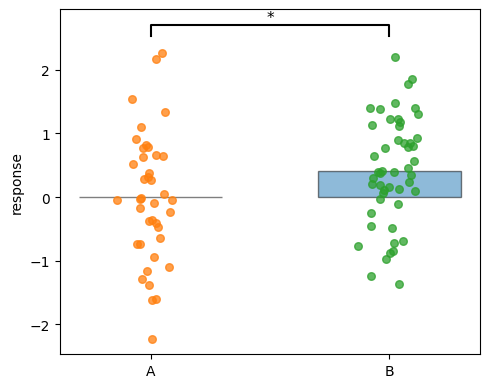

In [ ]:
tres = stats.ttest_ind(y_A, y_B, equal_var=True)
print("Two-sample t-test")
print(f"t = {tres.statistic:.3f}, p = {tres.pvalue:.5f}")
plot_two_group_jitter(df_t, x_col="condition", y_col="response", labels=["A", "B"], p_value=tres.pvalue)

## 1.2 Alternative method: Linear Regression + Bootstrapping

Intercept       -0.006175
condition_num    0.421806
dtype: float64
Bootstrap 95% CI for condition coefficient: [0.03183867 0.80138579]
REJECT null


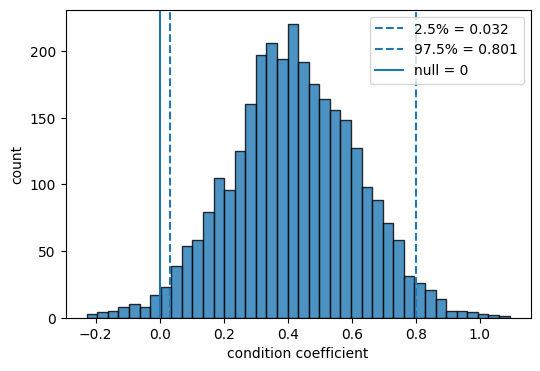

In [ ]:
df_t["condition_num"] = (df_t["condition"] == "B").astype(int)
fit_t = lambda d: smf.ols("response ~ condition_num", data=d).fit()
model_t = fit_t(df_t)
print(model_t.params)
vals_t, ci_t = bootstrap_coef(df_t, fit_t, "condition_num", n_boot=1000, random_state=1)
print("Bootstrap 95% CI for condition coefficient:", ci_t)
print(ci_decision(ci_t, 0))
plot_bootstrap(vals_t, ci_t, null_value=0, xlabel="condition coefficient")

# 2. One-way ANOVA

In [ ]:
n = 40
y_A = np.random.normal(0.0, 1.0, n)
y_B = np.random.normal(0.6, 1.0, n)
y_C = np.random.normal(1.1, 1.0, n)
df_a = pd.DataFrame({"response": np.r_[y_A, y_B, y_C], "condition": ["A"] * n + ["B"] * n + ["C"] * n})

## 2.1 Classical method

One-way ANOVA
F = 5.346, p = 0.00600


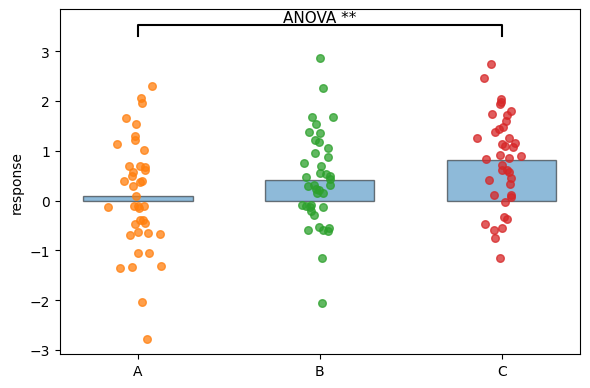

In [ ]:
fres = stats.f_oneway(y_A, y_B, y_C)
print("One-way ANOVA")
print(f"F = {fres.statistic:.3f}, p = {fres.pvalue:.5f}")
plot_three_group_jitter(df_a, x_col="condition", y_col="response", labels=["A", "B", "C"], p_value=fres.pvalue)

## 2.2 Alternative method: Linear Regression + Bootstrapping

Intercept            0.088660
C(condition)[T.B]    0.323701
C(condition)[T.C]    0.725694
dtype: float64
Bootstrap 95% CI for B vs A: [-0.11382581  0.76248891] | FAIL TO REJECT null
Bootstrap 95% CI for C vs A: [0.27771183 1.14834381] | REJECT null


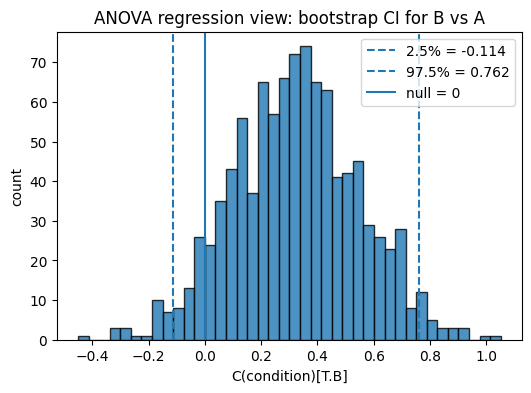

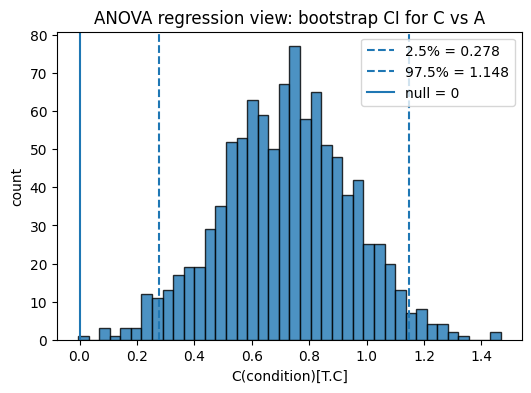

In [ ]:
fit_a = lambda d: smf.ols("response ~ C(condition)", data=d).fit()
model_a = fit_a(df_a)
print(model_a.params)
vals_B, ci_B = bootstrap_coef(df_a, fit_a, "C(condition)[T.B]", n_boot=1000, random_state=2)
vals_C, ci_C = bootstrap_coef(df_a, fit_a, "C(condition)[T.C]", n_boot=1000, random_state=3)
print("Bootstrap 95% CI for B vs A:", ci_B, "|", ci_decision(ci_B, 0))
print("Bootstrap 95% CI for C vs A:", ci_C, "|", ci_decision(ci_C, 0))
plot_bootstrap( vals_B, ci_B, null_value=0, title="bootstrap CI for B vs A", xlabel="C(condition)[T.B]")
plot_bootstrap(vals_C, ci_C, null_value=0, title="bootstrap CI for C vs A", xlabel="C(condition)[T.C]")

# 3. Pearson correlation

In [ ]:
n = 100
stimulus = np.random.normal(size=n)
response = 0.8 * stimulus + np.random.normal(scale=0.9, size=n)
df_r = pd.DataFrame({"stimulus": stimulus, "response": response})

## 3.1 Classical method

Pearson correlation
r = 0.660, p = 0.00000


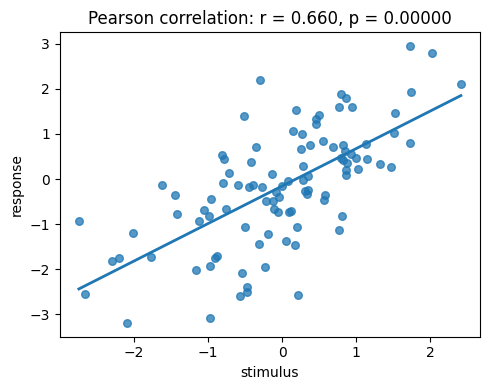

In [ ]:
rres = stats.pearsonr(df_r["stimulus"], df_r["response"])
print("Pearson correlation")
print(f"r = {rres.statistic:.3f}, p = {rres.pvalue:.5f}")
plot_scatter_with_fit(df_r["stimulus"], df_r["response"], xlabel="stimulus", ylabel="response", title=f"Pearson correlation: r = {rres.statistic:.3f}, p = {rres.pvalue:.5f}")

## 3.2 Alternative method: Linear Regression + Bootstrapping

Intercept   -0.157503
stimulus     0.831839
dtype: float64
Bootstrap 95% CI for slope: [0.6786073  1.01471725]
REJECT null


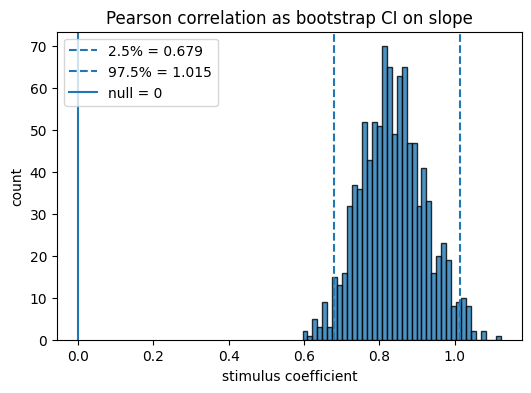

In [ ]:
fit_r = lambda d: smf.ols("response ~ stimulus", data=d).fit()
model_r = fit_r(df_r)
print(model_r.params)
vals_r, ci_r = bootstrap_coef(df_r, fit_r, "stimulus", n_boot=1000, random_state=5)
print("Bootstrap 95% CI for slope:", ci_r)
print(ci_decision(ci_r, 0))
plot_bootstrap(vals_r, ci_r, null_value=0, title="bootstrap CI on slope", xlabel="stimulus coefficient")

# 4. Chi-squared test

In [ ]:
nA, nB = 80, 100
p_A = 0.3
p_B = 0.6
detected_A = np.random.binomial(1, p_A, size=nA)
detected_B = np.random.binomial(1, p_B, size=nB)
df_chi = pd.DataFrame({"condition": ["A"] * nA + ["B"] * nB, "detected": np.r_[detected_A, detected_B]})
df_chi["condition_num"] = (df_chi["condition"] == "B").astype(int)

## 4.1 Classical method

detected    0   1
condition        
A          53  27
B          37  63

Chi-squared test
chi2 = 14.062, p = 0.00018


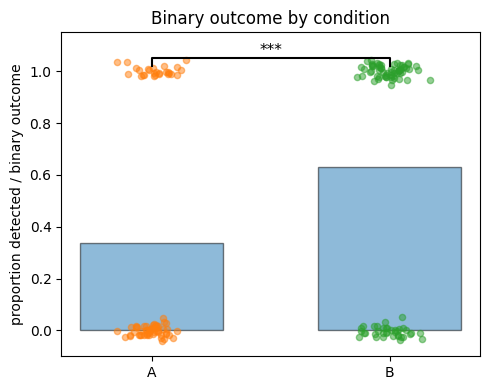

In [ ]:
table = pd.crosstab(df_chi["condition"], df_chi["detected"])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(table)
print("\nChi-squared test")
print(f"chi2 = {chi2:.3f}, p = {p:.5f}")
plot_binary_proportions(df_chi, x_col="condition", y_col="detected", labels=["A", "B"], title="Binary outcome by condition", p_value=p)

## 4.2 Alternative method: Logistic Regression + Bootstrapping

Intercept       -0.674455
condition_num    1.206672
dtype: float64
Bootstrap 95% CI for logistic condition coefficient: [0.59470234 1.84815704]
REJECT null


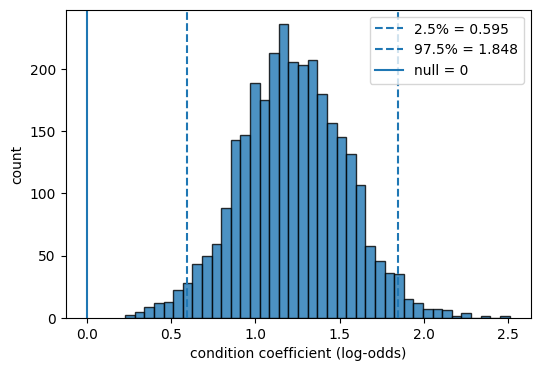

In [ ]:
fit_chi = lambda d: smf.logit("detected ~ condition_num", data=d).fit(disp=False)
model_chi = fit_chi(df_chi)
print(model_chi.params)
vals_chi, ci_chi = bootstrap_logit_coef(df_chi, fit_chi, "condition_num", n_boot=3000, random_state=6)
print("Bootstrap 95% CI for logistic condition coefficient:", ci_chi)
print(ci_decision(ci_chi, 0))
plot_bootstrap(vals_chi, ci_chi, null_value=0, xlabel="condition coefficient (log-odds)")

In [ ]:
summary = pd.DataFrame({
    "Classical test": [
        "Two-sample t-test",
        "One-way ANOVA",
        "Pearson correlation",
        "Chi-squared test (2x2)"
    ],
    "Regression model": [
        "response ~ condition_num",
        "response ~ C(condition)",
        "response ~ stimulus",
        "detected ~ condition_num"
    ],
    "Null": [
        "beta_condition = 0",
        "condition contrasts = 0",
        "beta_stimulus = 0",
        "beta_condition = 0"
    ]
})

summary

,Classical test,Regression model,Null
0,Two-sample t-test,response ~ condition_num,beta_condition = 0
1,One-way ANOVA,response ~ C(condition),condition contrasts = 0
2,Pearson correlation,response ~ stimulus,beta_stimulus = 0
3,Chi-squared test (2x2),detected ~ condition_num,beta_condition = 0
